## Modelling

In [1]:
# --------------------------------
# IMPORTS
# --------------------------------

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree
from xgboost import XGBRegressor


In [2]:
# --------------------------------
# PRESENTATION STYLE
# --------------------------------

sns.set_theme(
    style='whitegrid',
    context='talk'
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

In [3]:
# --------------------------------
# HELPER MODEL EVALUATION
# --------------------------------

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        'model': model_name,
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred)
    }

    return metrics, y_pred

In [4]:
# --------------------------------
# LOAD PROCESSED DATA
# --------------------------------

df = pd.read_csv('../01_data/02_processed_data/hour.csv')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,log_cnt,temp_diff,time_of_day,lag_1,lag_24,lag_168,rolling_24h,rolling_168h,weekday_hour_avg,trend_diff
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,2.833213,-0.0479,night,NaN,NaN,NaN,NaN,NaN,94.304762,NaN
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,3.713572,-0.0527,night,16.0,NaN,NaN,NaN,NaN,67.780952,NaN
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,3.496508,-0.0527,night,40.0,NaN,NaN,NaN,NaN,50.495238,NaN
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,2.639057,-0.0479,night,32.0,NaN,NaN,NaN,NaN,22.885714,NaN
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.693147,-0.0479,night,13.0,NaN,NaN,NaN,NaN,7.657143,NaN


In [5]:
# --------------------------------
# TRAIN TEST SPLIT
# --------------------------------

df['dteday'] = pd.to_datetime(df['dteday'])

df = df.sort_values(['dteday', 'hr']).reset_index(drop=True)

split_idx = int(len(df) * 0.8)

split_date = df.loc[split_idx, 'dteday']

df_train = df[df['dteday'] < split_date].copy()
df_test = df[df['dteday'] >= split_date].copy()

print('Train:', df_train.shape)
print('Test:', df_test.shape)

print(
    'Train time:',
    df_train['dteday'].min(),
    'til',
    df_train['dteday'].max()
)

print(
    'Test time:',
    df_test['dteday'].min(),
    "till",
    df_test['dteday'].max()
)


Train: (13891, 27)
Test: (3488, 27)
Train time: 2011-01-01 00:00:00 til 2012-08-06 00:00:00
Test time: 2012-08-07 00:00:00 till 2012-12-31 00:00:00


In [6]:
# --------------------------------
# FEATURES SELECTIONS BASELINE
# --------------------------------

FEATURES_BASELINE = {
    'season': 'categorical',
    'yr': 'binary',
    'mnth': 'categorical',
    'hr': 'categorical',
    'holiday': 'binary',
    'weekday': 'categorical',
    'workingday': 'binary',
    'weathersit': 'categorical',
    'temp': 'numerical',
    'hum': 'numerical',
    'windspeed': 'numerical',
}


target_original = df['cnt']
target_log = df['log_cnt']



## Baseline Model

In [7]:
# --------------------------------
# RANDOM FOREST REGRESSOR - BASELINE
# --------------------------------

# Note:
# For the baseline model, a time-based holdout test split was initially used.
# Cross-validation is then used to compare model variants and tune hyperparameters.


# --------------------------------
# FEATURE GROUPS
# --------------------------------

categorical_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == 'categorical'
]

binary_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == 'binary'
]

numerical_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == 'numerical'
]


# --------------------------------
# TRAIN / TEST DATA
# --------------------------------

feature_columns = list(FEATURES_BASELINE.keys())

X_train = df_train[feature_columns]
y_train = df_train["cnt"]

X_test = df_test[feature_columns]
y_test = df_test['cnt']


# --------------------------------
# PREPROCESSING
# --------------------------------

ct_baseline = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features_baseline
        ),
        (
            'bin',
            'passthrough',
            binary_features_baseline
        ),
        (
            'num',
            'passthrough',
            numerical_features_baseline
        ),
    ]
)


# --------------------------------
# MODEL
# --------------------------------

rfr_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# --------------------------------
# PIPELINE
# --------------------------------

pipeline_baseline = Pipeline([
    ('preprocess', ct_baseline),
    ('model', rfr_baseline)
])


# --------------------------------
# TRAIN & EVALUATE
# --------------------------------

metrics_rfr_baseline, target_test_original_pred = evaluate_model(
    'RF Baseline',
    pipeline_baseline,
    X_train,
    y_train,
    X_test,
    y_test
)

print(metrics_rfr_baseline)

{'model': 'RF Baseline', 'R2': 0.8622035838774824, 'MAE': 54.56906510416666, 'RMSE': 81.84898147844295}


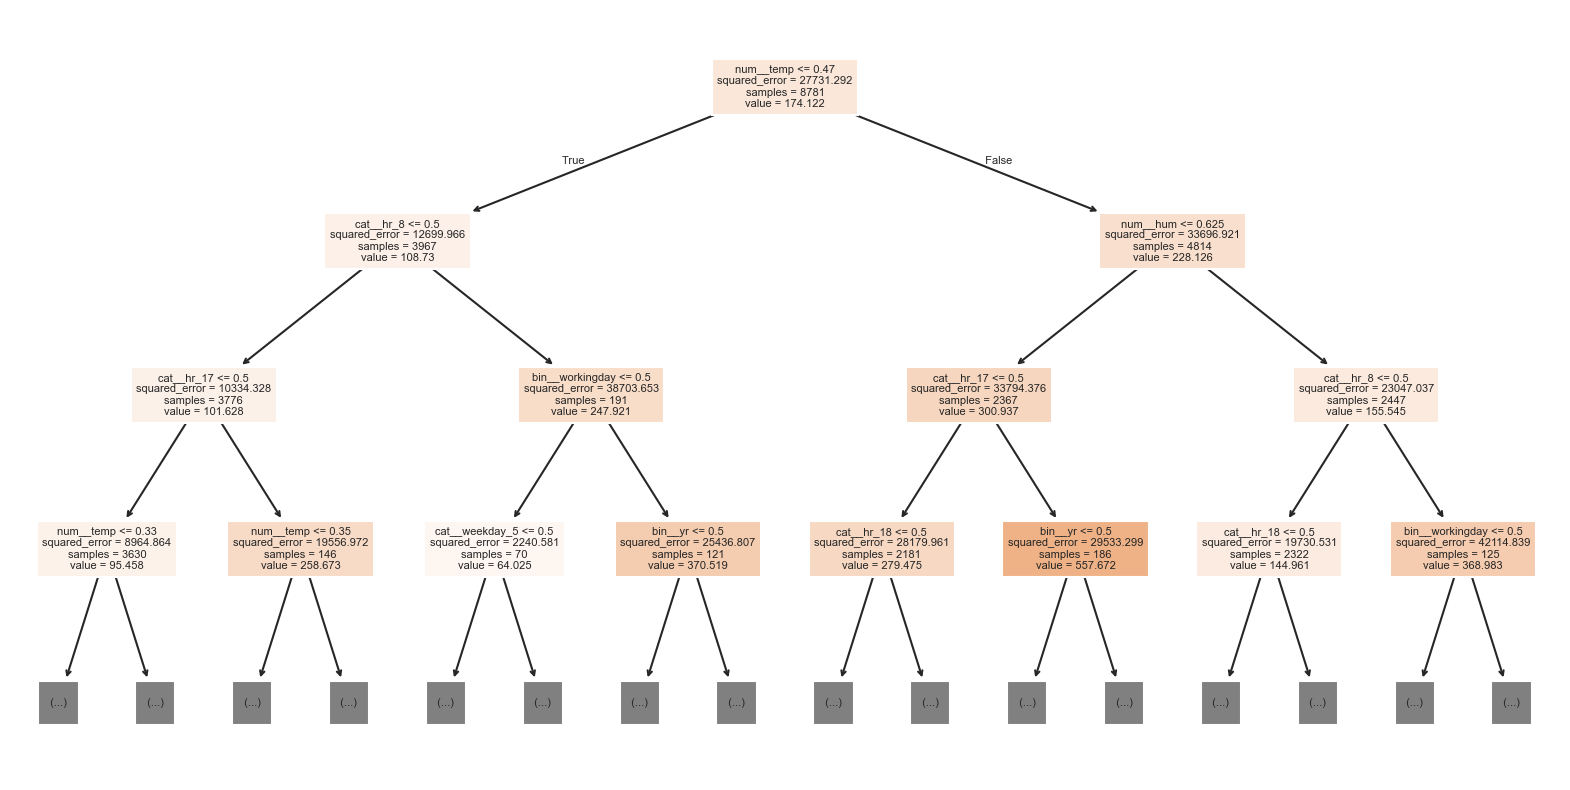

In [8]:
rfr_model = pipeline_baseline.named_steps['model']


plt.figure(figsize=(20, 10))

plot_tree(
    rfr_model.estimators_[0],
    max_depth=3,
    filled=True,
    feature_names=pipeline_baseline.named_steps['preprocess'].get_feature_names_out(),
    fontsize=8
)

plt.show()

In [9]:
rfr_model = pipeline_baseline.named_steps['model']
preprocessor = pipeline_baseline.named_steps['preprocess']

feature_names = preprocessor.get_feature_names_out()
importance = rfr_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance.head(20))

            feature  importance
54        num__temp    0.181106
55         num__hum    0.138047
53  bin__workingday    0.085973
33       cat__hr_17    0.083888
34       cat__hr_18    0.074374
51          bin__yr    0.062940
24        cat__hr_8    0.062107
35       cat__hr_19    0.032374
23        cat__hr_7    0.018266
17        cat__hr_1    0.016091
18        cat__hr_2    0.015625
56   num__windspeed    0.015522
19        cat__hr_3    0.014591
16        cat__hr_0    0.014241
20        cat__hr_4    0.014088
32       cat__hr_16    0.013528
21        cat__hr_5    0.013064
36       cat__hr_20    0.012172
39       cat__hr_23    0.010881
25        cat__hr_9    0.010876


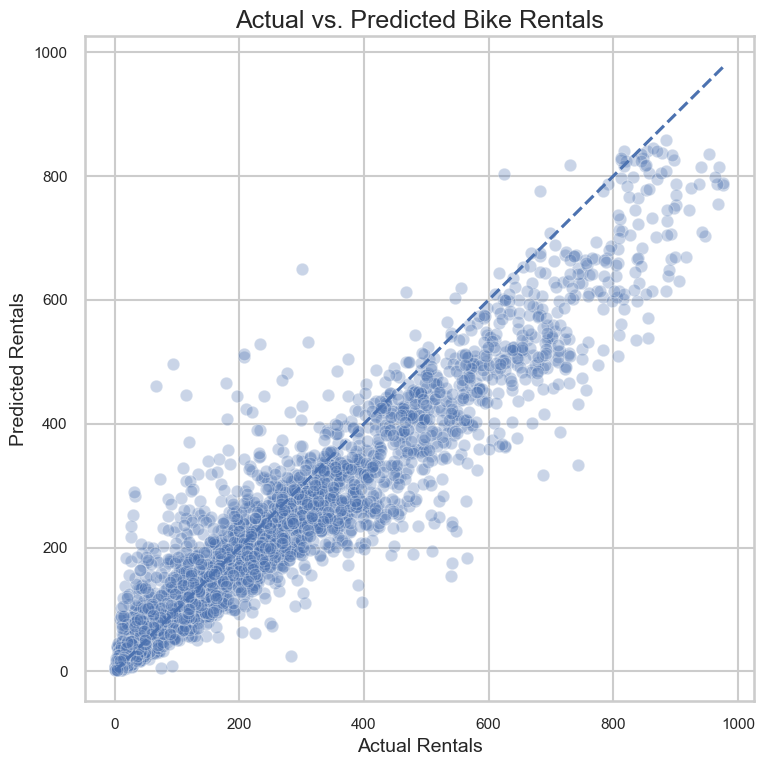

In [10]:
# --------------------------------
# ACTUAL VS PREDICTED
# --------------------------------

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=df_test['cnt'],
    y=target_test_original_pred,
    alpha=0.3
)

min_value = min(
    df_test['cnt'].min(),
    target_test_original_pred.min()
)

max_value = max(
    df_test['cnt'].max(),
    target_test_original_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title('Actual vs. Predicted Bike Rentals')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')

plt.tight_layout()
plt.show()

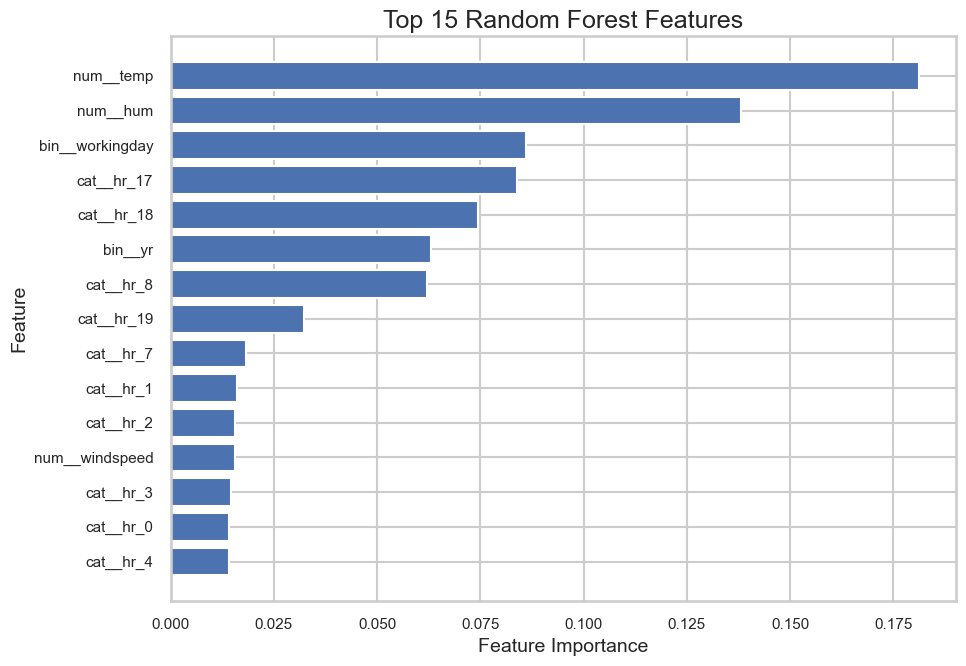

In [11]:
# --------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# --------------------------------

rfr_model = pipeline_baseline.named_steps['model']
preprocessor = pipeline_baseline.named_steps['preprocess']

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = rfr_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })
    .sort_values(
        'importance',
        ascending=False
    )
    .head(15)
    .sort_values(
        'importance'
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance['feature'],
    feature_importance['importance']
)

plt.title('Top 15 Random Forest Features')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [12]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE
# --------------------------------

rfr_model = pipeline_baseline.named_steps['model']
preprocessor = pipeline_baseline.named_steps['preprocess']

feature_names = preprocessor.get_feature_names_out()
importance = rfr_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance['original_feature'] = (
    feature_importance['feature']
    .str.replace(r"^(cat|bin|num)__", "", regex=True)
    .str.extract(r"^([a-zA-Z_]+)", expand=False)
)

for feature in categorical_features_baseline:
    feature_importance.loc[
        feature_importance['feature'].str.startswith(f"cat__{feature}_"),
        'original_feature'
    ] = feature

for feature in binary_features_baseline + numerical_features_baseline:
    feature_importance.loc[
        feature_importance['feature'].eq(f"bin__{feature}") |
        feature_importance['feature'].eq(f"num__{feature}"),
        'original_feature'
    ] = feature

grouped_importance = (
    feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

display(grouped_importance)

original_feature
hr            0.447805
temp          0.181106
hum           0.138047
workingday    0.085973
yr            0.062940
weekday       0.019417
mnth          0.017125
season        0.017055
windspeed     0.015522
weathersit    0.013842
holiday       0.001169
Name: importance, dtype: float64

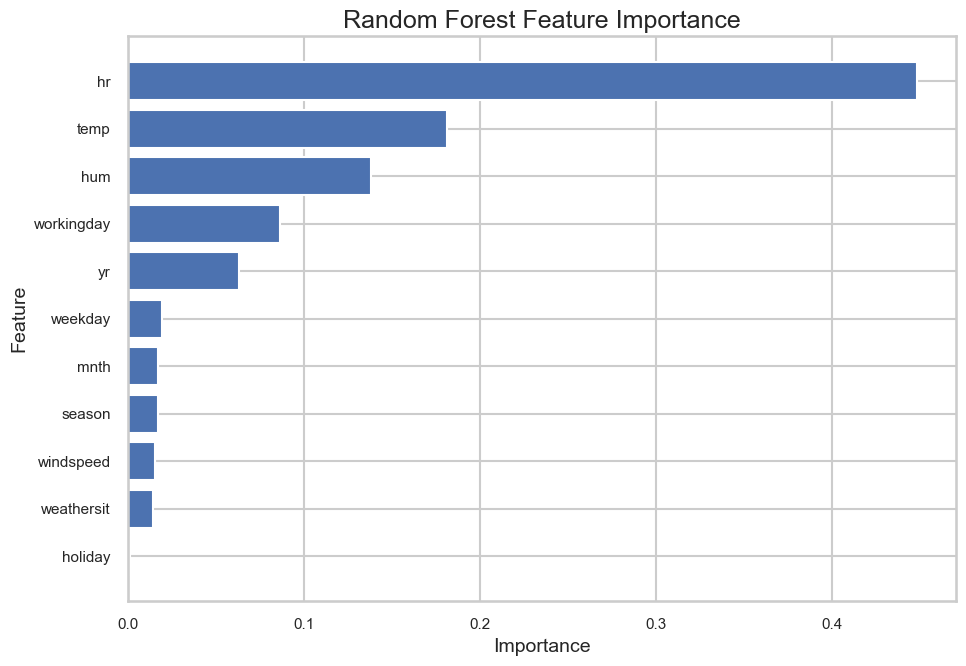

In [13]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE PLOT
# --------------------------------

plot_data = (
    grouped_importance
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data.index,
    plot_data.values
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

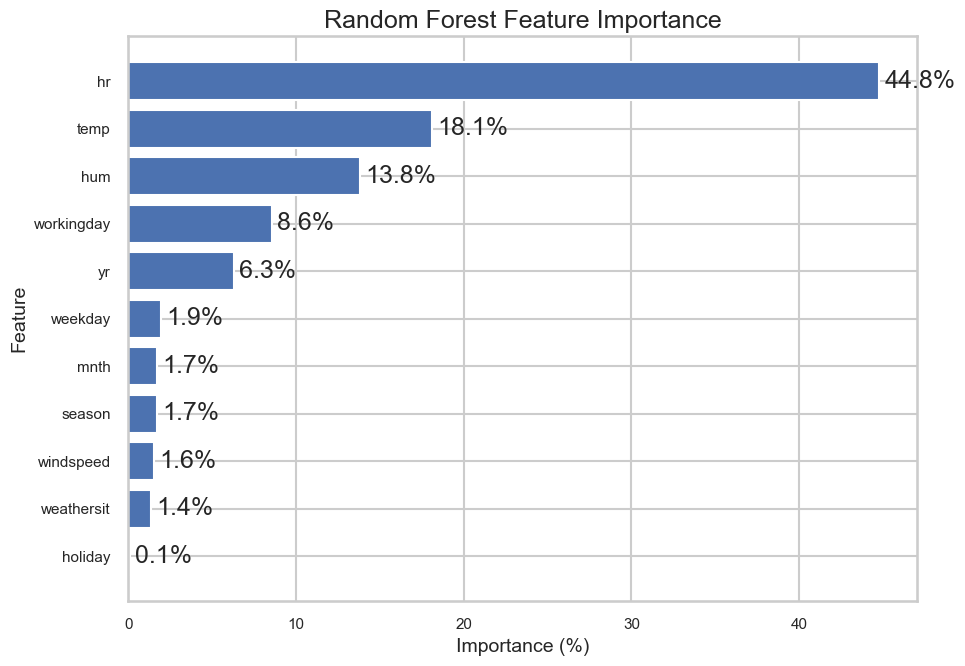

In [14]:
grouped_importance_pct = (
    grouped_importance / grouped_importance.sum() * 100
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    grouped_importance_pct.index,
    grouped_importance_pct.values
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')

for bar, value in zip(bars, grouped_importance_pct.values):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va='center'
    )

plt.tight_layout()
plt.show()

## Feature engineered models

In [15]:
# --------------------------------
# FEATURE COLUMNS v01
# --------------------------------

FEATURES_V01 = {
    'season': 'categorical',
    'yr': 'binary',
    'mnth': 'categorical',
    'hr': 'categorical',
    'time_of_day': 'categorical',          # new feature 
    'holiday': 'binary',
    'weekday': 'categorical',
    'workingday': 'binary',
    'weathersit': 'categorical',
    'temp': 'numerical',
    'temp_diff': 'numerical',             # new feature
    'hum': 'numerical',
    'windspeed': 'numerical',
    'lag_1': 'numerical', 
    'lag_24': 'numerical',
    'lag_168': 'numerical',
    'rolling_24h': 'numerical', 
    'rolling_168h': 'numerical',
    'weekday_hour_avg': 'numerical', 
    'trend_diff': 'numerical'
}


categorical_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == 'categorical'
]

binary_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == 'binary'
]

numerical_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == 'numerical'
]

feature_columns = list(FEATURES_V01.keys())


X_train_v01 = df_train[feature_columns]
y_train = df_train['cnt']

X_test_v01 = df_test[feature_columns]
y_test = df_test['cnt']


In [16]:
# --------------------------------
# MODELL DEFINITIONS
# --------------------------------

# Random Forest
rfr_01 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# Linear Regression
reg_01 = LinearRegression()


# XGBoost
xgb_01 = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Model collection
models = {
    'Random Forest': rfr_01,
    'Linear Regression': reg_01,
    'XGBoost': xgb_01
}

In [17]:
# Random Forest
ct_rfr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', SimpleImputer(strategy='most_frequent'), binary_features),
        ('num', SimpleImputer(strategy='median'), numerical_features),
    ]
)

pipeline_rfr = Pipeline([
    ('preprocess', ct_rfr),
    ('model', rfr_01)
])


# Linear Regression

ct_reg = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ('bin', SimpleImputer(strategy='most_frequent'), binary_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
    ]
)

pipeline_reg = Pipeline([
    ('preprocess', ct_reg),
    ('model', reg_01)
])


# XGBoost
ct_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', SimpleImputer(strategy='most_frequent'), binary_features),
        ('num', SimpleImputer(strategy='median'), numerical_features),
    ]
)

pipeline_xgb = Pipeline([
    ('preprocess', ct_xgb),
    ('model', xgb_01)
])

In [18]:
# --------------------------------
# OVERVIEW METRICS
# --------------------------------

results = []

metrics_rfr, y_pred_rfr = evaluate_model(
    'Random Forest',
    pipeline_rfr,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_rfr)

metrics_reg, y_pred_reg = evaluate_model(
    'Linear Regression',
    pipeline_reg,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_reg)

metrics_xgb, y_pred_xgb = evaluate_model(
    'XGBoost',
    pipeline_xgb,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_xgb)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        'RMSE',
        ascending=True
    )
)

,model,R2,MAE,RMSE
2,XGBoost,0.957450,29.120710,45.482281
0,Random Forest,0.954892,28.902847,46.829660
1,Linear Regression,0.903318,47.994169,68.559353


- Over the specified test period, XGBoost achieves the best performance to date. 

- Feature engineering further improves upon the random forest baseline.

- No follow up on Linear Regression

In [19]:
tscv = TimeSeriesSplit(n_splits=5)

In [53]:
# Linear Regression

cv_reg = cross_validate(
    pipeline_reg,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
    },
    return_train_score=False,
    error_score="raise",
)

print("Lin Regression Engineered")
print("Mean R2:", cv_reg["test_r2"].mean())
print("Mean MAE:", -cv_reg["test_mae"].mean())
print("Mean RMSE:", -cv_reg["test_rmse"].mean())

Lin Regression Engineered
Mean R2: 0.8764369134638839
Mean MAE: 39.74461978691299
Mean RMSE: 56.52229208768212


In [20]:
# RandomForestRegressor

cv_rfr = cross_validate(
    pipeline_rfr,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
    },
    return_train_score=False,
    error_score="raise",
)

print("RF Engineered")
print("Mean R2:", cv_rfr["test_r2"].mean())
print("Mean MAE:", -cv_rfr["test_mae"].mean())
print("Mean RMSE:", -cv_rfr["test_rmse"].mean())

RF Engineered
Mean R2: 0.8610018910573471
Mean MAE: 36.20579611231101
Mean RMSE: 57.20949325578689


In [21]:
# XGBoost

cv_xgb = cross_validate(
    pipeline_xgb,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
    },
    return_train_score=False,
    error_score='raise',
)

print('XGBoost')
print('Mean R2:', cv_xgb['test_r2'].mean())
print('Mean MAE:', -cv_xgb['test_mae'].mean())
print('Mean RMSE:', -cv_xgb['test_rmse'].mean())

XGBoost
Mean R2: 0.8603201746940613
Mean MAE: 37.34043197631836
Mean RMSE: 57.020206451416016


In [22]:
cv_xgb_df = pd.DataFrame({
    'fold': range(1, len(cv_xgb['test_r2']) + 1),
    'R2': cv_xgb['test_r2'],
    'MAE': -cv_xgb['test_mae'],
    'RMSE': -cv_xgb['test_rmse']
})

display(cv_xgb_df.round(3))

,fold,R2,MAE,RMSE
0,1,0.665,60.071,86.353
1,2,0.928,25.395,39.563
2,3,0.906,23.871,36.368
3,4,0.869,39.694,67.143
4,5,0.934,37.671,55.674


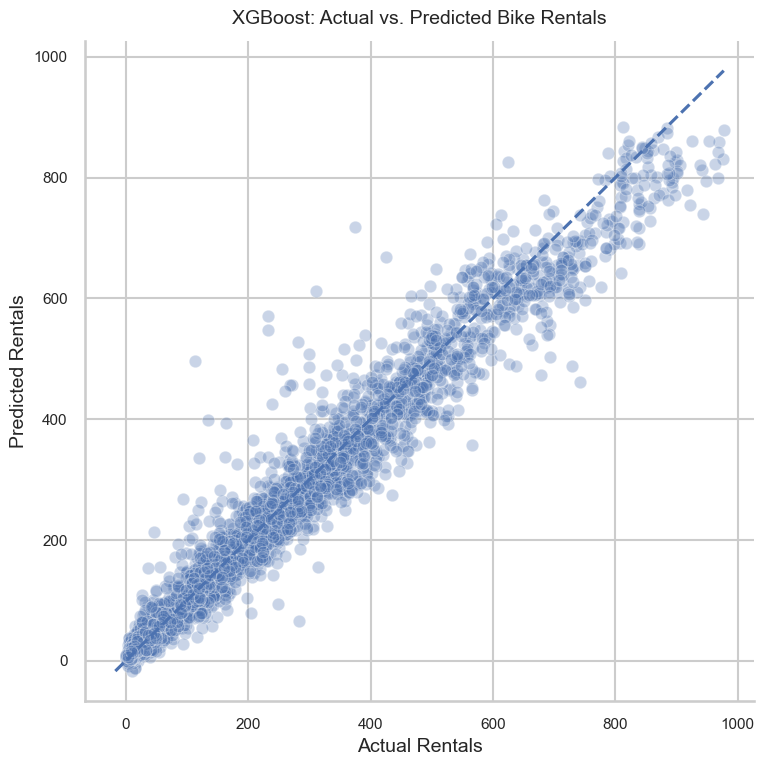

In [51]:
# --------------------------------
# ACTUAL VS PREDICTED - XGBOOST
# --------------------------------


r2 = r2_score(y_test, y_pred_xgb)

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.3
)

min_value = min(
    y_test.min(),
    y_pred_xgb.min()
)

max_value = max(
    y_test.max(),
    y_pred_xgb.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

# plt.text(
#    0.05,
#    0.95,
#    f"$R^2$ = {r2:.3f}",
#    transform=plt.gca().transAxes,
#    fontsize=12,
#    verticalalignment="top"
#)

plt.title('XGBoost: Actual vs. Predicted Bike Rentals', fontsize=14, pad=12)
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

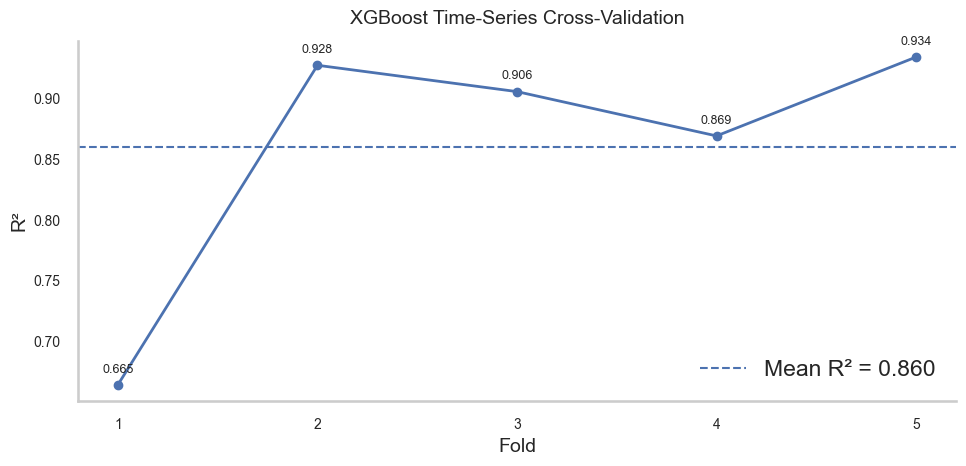

In [24]:
cv_plot = cv_xgb_df.copy()

mean_r2 = cv_plot['R2'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    cv_plot['fold'],
    cv_plot['R2'],
    marker='o',
    linewidth=2,
    markersize=6
)

ax.axhline(
    mean_r2,
    linestyle='--',
    linewidth=1.5,
    label=f"Mean R² = {mean_r2:.3f}"
)

for x, y in zip(cv_plot['fold'], cv_plot['R2']):
    ax.text(
        x,
        y + 0.01,
        f"{y:.3f}",
        ha='center',
        fontsize=9
    )

ax.set_title(
    'XGBoost Time-Series Cross-Validation',
    fontsize=14,
    pad=12
)

ax.set_xlabel('Fold')
ax.set_ylabel('R²')

ax.set_xticks(cv_plot['fold'])

ax.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.tick_params(
    axis='both',
    labelsize=10
)

ax.legend(
    frameon=False,
    loc='best'
)

plt.tight_layout()
plt.show()

In [25]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE
# XGBoost
# --------------------------------

xgb_model = pipeline_xgb.named_steps['model']
preprocessor = pipeline_xgb.named_steps['preprocess']

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance['original_feature'] = (
    feature_importance['feature']
    .str.replace(r"^(cat|bin|num)__", "", regex=True)
)

for feature in categorical_features:
    feature_importance.loc[
        feature_importance['feature'].str.startswith(
            f"cat__{feature}_"
        ),
        'original_feature'
    ] = feature

grouped_importance = (
    feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

display(grouped_importance)

original_feature
lag_1               0.360000
time_of_day         0.180645
weekday_hour_avg    0.135255
hr                  0.126322
rolling_168h        0.043686
yr                  0.022871
weathersit          0.021764
mnth                0.019475
workingday          0.018333
rolling_24h         0.016447
lag_24              0.012090
holiday             0.011325
weekday             0.011229
temp                0.005342
season              0.004028
lag_168             0.003917
trend_diff          0.002227
hum                 0.002116
windspeed           0.001623
temp_diff           0.001303
Name: importance, dtype: float32

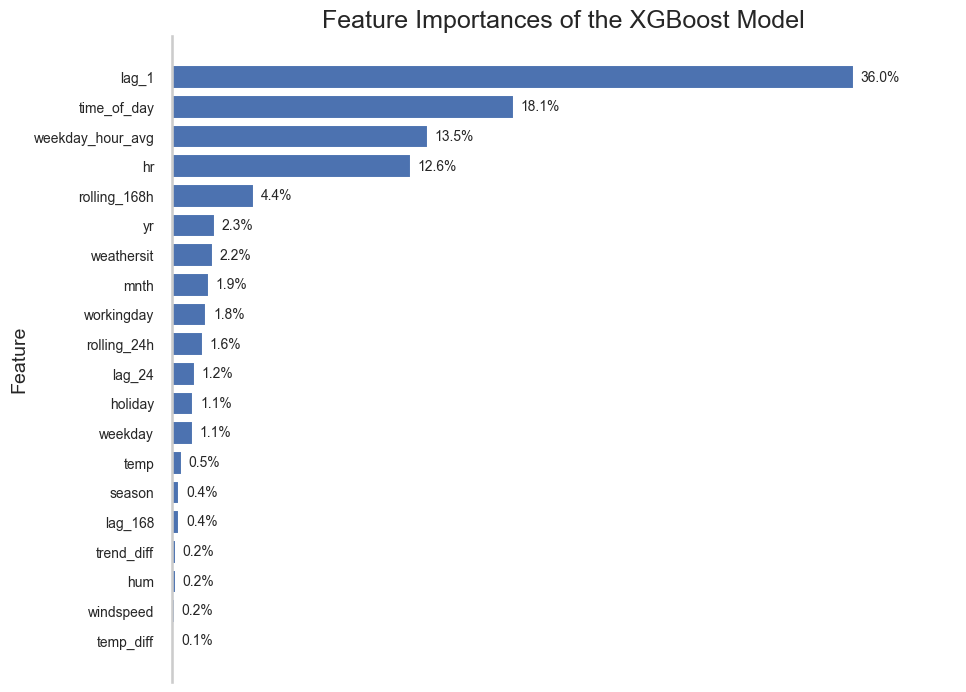

In [26]:
# --------------------------------
# PLOT GROUPED FEATURE IMPORTANCE
# --------------------------------


plt.close('all')  

grouped_importance_pct = (
    grouped_importance / grouped_importance.sum() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    grouped_importance_pct.index,
    grouped_importance_pct.values
)

ax.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)

ax.tick_params(
    axis='y',
    labelsize=10
)

ax.set_xlabel('')
ax.set_ylabel('Feature')

ax.grid(False)

for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

max_value = grouped_importance_pct.max()

for i, value in enumerate(grouped_importance_pct.values):
    ax.text(
        value + max_value * 0.01,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

ax.set_xlim(0, max_value * 1.15)

plt.tight_layout()
plt.title('Feature Importances of the XGBoost Model')
plt.show()

In [27]:
# --------------------------------
# HYPERPARAMETER TUNING
# --------------------------------


def objective(trial):

    params = {
        "model__learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),

        "model__max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),

        "model__min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 15
        ),

        "model__subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),

        "model__colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        "model__reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),

        "model__reg_lambda": trial.suggest_float(
            "reg_lambda", 1, 20
        ),

        "model__n_estimators": trial.suggest_int(
            "n_estimators", 300, 1500
        )
    }


    model = clone(pipeline_xgb)
    model.set_params(**params)


    cv = cross_validate(
        model,
        X_train_v01,
        y_train,
        cv=tscv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        return_train_score=False,
        error_score="raise"
    )


    mean_rmse = -cv["test_rmse"].mean()

    return mean_rmse

In [28]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-08-24 11:18:03,131] A new study created in memory with name: no-name-eecc084d-b8ba-4246-9429-664fc897d886


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-24 11:18:10,264] Trial 0 finished with value: 56.138433837890624 and parameters: {'learning_rate': 0.052513017985972035, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.9303138858604536, 'colsample_bytree': 0.8088140907799096, 'reg_alpha': 3.3219343130965244, 'reg_lambda': 4.310070156899166, 'n_estimators': 898}. Best is trial 0 with value: 56.138433837890624.
[I 2026-08-24 11:18:19,286] Trial 1 finished with value: 55.26688003540039 and parameters: {'learning_rate': 0.017554118048899843, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.8386889481071239, 'colsample_bytree': 0.7009487268975219, 'reg_alpha': 2.0972123337724997, 'reg_lambda': 3.0796773887230415, 'n_estimators': 1013}. Best is trial 1 with value: 55.26688003540039.
[I 2026-08-24 11:18:24,556] Trial 2 finished with value: 53.26929473876953 and parameters: {'learning_rate': 0.030825241674598828, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.8442388384161795, 'colsample_bytree': 0.983508609127178

In [34]:
print(study.best_params)
print(study.best_value)

{'learning_rate': 0.03441796109600408, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.9327237906661943, 'colsample_bytree': 0.7421855501955125, 'reg_alpha': 2.2742507753552976, 'reg_lambda': 5.321786966584747, 'n_estimators': 1353}
50.60424118041992


## Best Model

In [35]:
best_model = clone(pipeline_xgb)
best_model.set_params(**{
    f"model__{k}": v 
    for k, v in study.best_params.items()
})

cv_best = cross_validate(
    best_model,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    return_train_score=False
)

print(-cv_best["test_rmse"])
print(cv_best["test_r2"])

[74.57419586 36.65756989 33.59011459 58.77574539 49.42358017]
[0.74983835 0.93777263 0.91968048 0.8998996  0.94821876]


In [ ]:
best_model.fit(
    X_train_v01,
    y_train
)

In [55]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE
# XGBoost (OPTUNA)
# --------------------------------

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance['original_feature'] = (
    feature_importance['feature']
    .str.replace(r"^(cat|bin|num)__", "", regex=True)
)

for feature in categorical_features:
    feature_importance.loc[
        feature_importance['feature'].str.startswith(
            f"cat__{feature}_"
        ),
        'original_feature'
    ] = feature

grouped_importance = (
    feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

display(grouped_importance)

original_feature
lag_1               0.307489
time_of_day         0.141240
weekday_hour_avg    0.099167
hr                  0.086281
lag_168             0.082051
lag_24              0.056922
weathersit          0.050745
rolling_24h         0.043182
rolling_168h        0.034697
yr                  0.020476
weekday             0.014935
mnth                0.014852
temp                0.011566
season              0.009220
workingday          0.008562
holiday             0.007194
trend_diff          0.006207
hum                 0.002717
windspeed           0.001361
temp_diff           0.001137
Name: importance, dtype: float32

In [ ]:
# --------------------------------
# SHAP
# XGBoost (OPTUNA)
# --------------------------------

preprocessor = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

X_transformed = preprocessor.transform(X_train_v01)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)

In [37]:
feature_names = preprocessor.get_feature_names_out()

len(feature_names), X_transformed.shape

(70, (13891, 70))

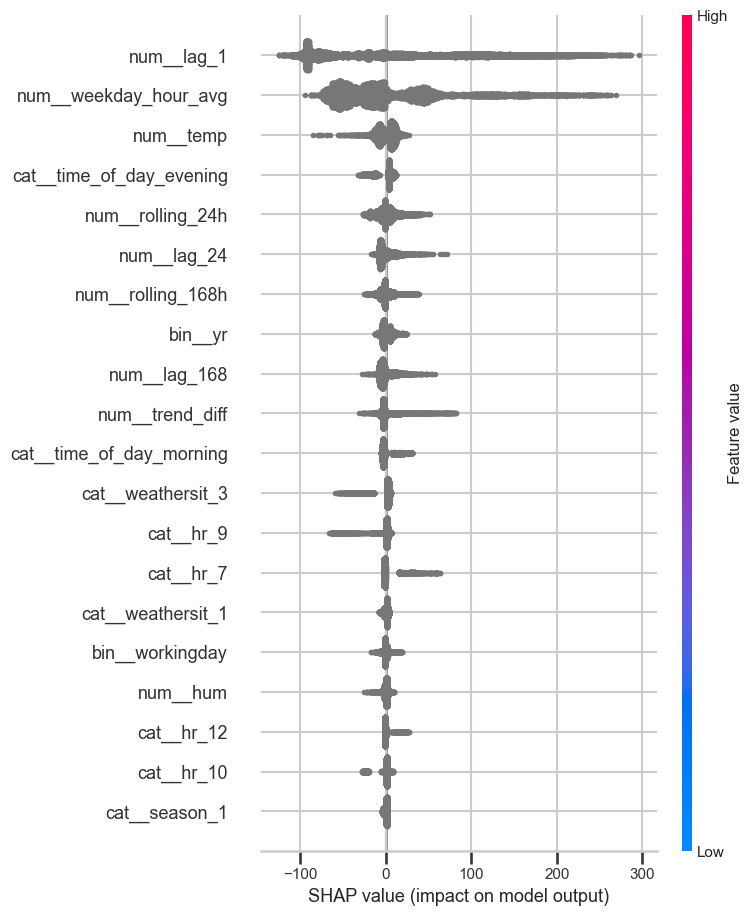

In [38]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

In [39]:
cv_best = cross_validate(
    best_model,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    return_train_score=False,
    error_score="raise",
)

print("XGBoost Optuna")

print("Mean R2:", cv_best["test_r2"].mean())
print("Mean MAE:", -cv_best["test_mae"].mean())
print("Mean RMSE:", -cv_best["test_rmse"].mean())

XGBoost Optuna
Mean R2: 0.891081964969635
Mean MAE: 33.00053253173828
Mean RMSE: 50.60424118041992


In [ ]:
best_model.fit(X_train_v01, y_train)

train_pred = best_model.predict(X_train_v01)

print(r2_score(y_train, train_pred))

0.9759954214096069
